# Rocket Trading Platform - Analytics & Audit Dashboard

**Multi-User Analytics Platform** serving two critical business functions:

- **David (Head of Trading Operations)**: Trade audit trails, dispute resolution, predictive modeling, business logic insights
- **Priya (Commercial Analyst)**: Monthly trends, volume analysis, risk metrics, executive reporting

This notebook separates operational analytics from strategic reporting to optimize query performance and data freshness.

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# Load environment variables
load_dotenv()

# Database connection parameters
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = int(os.getenv('DB_PORT', '5433'))
DB_NAME = os.getenv('DB_NAME', 'team_rocket_db')
DB_USER = os.getenv('DB_USER', 'team_rocket_admin')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'team_rocket_password123')

# Set up visualization style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 7)

print(f"✓ Connected to {DB_NAME} at {DB_HOST}:{DB_PORT}")
print("✓ Analytics platform initialized for David & Priya")

✓ Connected to team_rocket_db at localhost:5432
✓ Analytics platform initialized for David & Priya


In [2]:
def query_to_df(query, show_query=False):
    """Execute SQL query and return result as DataFrame using SQLAlchemy"""
    encoded_password = quote_plus(DB_PASSWORD)
    database_url = f"postgresql://{DB_USER}:{encoded_password}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(database_url)
    
    try:
        if show_query:
            print(f"Executing: {query[:100]}...")
        df = pd.read_sql_query(query, engine)
        return df
    finally:
        engine.dispose()

print("✓ Database query helper initialized")

✓ Database query helper initialized


---

# 🔍 DAVID'S OPERATIONS DASHBOARD
## Head of Trading Operations - Audit & Dispute Resolution

**Purpose**: Complete trade audit trail, transaction history, and predictive analytics for resolving disputes and understanding operational patterns.

**Key Responsibilities**:
- Trade dispute resolution (exact what/when/how)
- Audit trail compliance
- Predictive modeling for trading patterns
- Business logic optimization

## 1. Trade Audit Trail & Dispute Resolution

Complete immutable record of every trade: what was ordered, what was filled, at what price, and when.

In [21]:
# Professional styling function - cleaner and more readable
def style_professional_dispute_table(df):
    """Apply professional styling to dispute table"""
    
    def highlight_status(val):
        """Color code status column"""
        if val == 'FILLED':
            return 'background-color: #10b981; color: white; font-weight: bold; font-size: 13px;'
        elif val == 'SUBMITTED':
            return 'background-color: #f59e0b; color: white; font-weight: bold; font-size: 13px;'
        elif val == 'REJECTED':
            return 'background-color: #ef4444; color: white; font-weight: bold; font-size: 13px;'
        return ''
    
    def highlight_side(val):
        """Color code Buy/Sell"""
        if val == 'BUY':
            return 'background-color: #dbeafe; color: #0369a1; font-weight: bold; font-size: 13px;'
        elif val == 'SELL':
            return 'background-color: #fce7f3; color: #be185d; font-weight: bold; font-size: 13px;'
        return ''
    
    def format_text(val):
        """Make text black"""
        return 'color: #000000; font-weight: 500; font-size: 13px;'
    
    # Apply styling with larger fonts and better spacing
    styled = df.style\
        .applymap(lambda val: highlight_status(val), subset=['Status'])\
        .applymap(lambda val: highlight_side(val), subset=['Side'])\
        .applymap(lambda val: format_text(val), subset=['Order', 'Client', 'Ticker', 'Req Qty', 'Exec Qty', 'Submitted', 'Executed', 'Price'])\
        .set_properties(**{'text-align': 'left', 'font-family': 'Menlo, monospace', 'font-size': '13px', 'padding': '10px'})\
        .set_table_styles([\
            {'selector': 'thead', 'props': [('background-color', '#1f2937'), ('color', 'white'), ('font-weight', 'bold'), ('font-size', '13px'), ('padding', '12px'), ('text-align', 'center')]},\
            {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#f9fafb')]},\
            {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#ffffff')]},\
            {'selector': 'tbody tr:hover', 'props': [('background-color', '#e0f2fe'), ('box-shadow', 'inset 0 0 5px rgba(0, 0, 0, 0.05)')]},\
            {'selector': 'th', 'props': [('border', '1px solid #374151'), ('padding', '12px'), ('text-align', 'center')]},\
            {'selector': 'td', 'props': [('border', '1px solid #e5e7eb'), ('padding', '10px')]}\
        ])
    
    return styled

# Display professionally styled table
display(style_professional_dispute_table(dispute_display))

,Order,Client,Ticker,Side,Req Qty,Exec Qty,Status,Submitted,Executed,Price
0,66,James Mitchell,VOW3,BUY,2.000000,2.000000,FILLED,09/23 19:46,09/23 21:34,$189.79
1,65,Michael Brown,SAP,BUY,1.000000,1.000000,FILLED,09/23 19:46,09/23 20:32,$94.37
2,64,Emma Thompson,GOOGL,BUY,5.000000,0.000000,SUBMITTED,09/23 19:46,⏳,—
3,69,Michael Brown,ASML,BUY,3.000000,0.000000,SUBMITTED,09/22 19:46,⏳,—
4,68,Edward Martin,ASML,BUY,1.000000,1.000000,FILLED,09/22 19:46,09/22 20:48,$629.37
5,67,Michael Brown,GOOGL,BUY,3.000000,0.000000,SUBMITTED,09/22 19:46,⏳,—
6,73,Robert Taylor,MSFT,BUY,4.000000,4.000000,FILLED,09/21 19:46,09/21 20:49,$383.85
7,72,James Mitchell,AAPL,BUY,5.000000,5.000000,FILLED,09/21 19:46,09/21 19:53,$179.38
8,71,Edward Martin,SAP,BUY,1.000000,1.000000,FILLED,09/21 19:46,09/21 19:56,$94.63
9,70,Sarah Davies,BTCUSD,BUY,2.000000,2.000000,FILLED,09/21 19:46,09/21 21:09,$46933.95


## 2. Complete Transaction History

Full ledger of all money and security movements (buys, sells, deposits, withdrawals, dividends).

In [14]:
transaction_query = """
SELECT 
    t.transaction_id,
    cp.client_full_name,
    ca.account_type,
    fi.ticker_symbol,
    t.transaction_type,
    t.quantity,
    t.unit_price,
    t.net_amount,
    t.transaction_date,
    f.order_id,
    f.executed_price,
    f.executed_at
FROM transactions t
JOIN client_accounts ca ON t.account_id = ca.account_id
JOIN client_profiles cp ON ca.client_id = cp.client_id
LEFT JOIN financial_instruments fi ON t.instrument_id = fi.instrument_id
LEFT JOIN fills f ON t.fill_id = f.fill_id
ORDER BY t.transaction_date DESC
LIMIT 100;
"""

transaction_df = query_to_df(transaction_query)
print(f"\n💰 COMPLETE TRANSACTION LEDGER ({len(transaction_df)} transactions)")
print("="*150)
display(transaction_df)


💰 COMPLETE TRANSACTION LEDGER (80 transactions)


,transaction_id,client_full_name,account_type,ticker_symbol,transaction_type,quantity,unit_price,net_amount,transaction_date,order_id,executed_price,executed_at
0,96,Michael Brown,GIA,None,WITHDRAWAL,NaN,NaN,-94.3700,2026-09-23 19:46:57.214477+00:00,65,94.3700,2026-09-23 20:32:57.218071+00:00
1,95,Michael Brown,GIA,SAP,BUY,1.0,94.3700,94.3700,2026-09-23 19:46:57.214477+00:00,65,94.3700,2026-09-23 20:32:57.218071+00:00
2,98,James Mitchell,SIPP,None,WITHDRAWAL,NaN,NaN,-379.5732,2026-09-23 19:46:57.214477+00:00,66,189.7866,2026-09-23 21:34:57.234820+00:00
3,97,James Mitchell,SIPP,VOW3,BUY,2.0,189.7866,379.5732,2026-09-23 19:46:57.214477+00:00,66,189.7866,2026-09-23 21:34:57.234820+00:00
4,100,Edward Martin,SIPP,None,WITHDRAWAL,NaN,NaN,-629.3719,2026-09-23 19:46:57.214477+00:00,68,629.3719,2026-09-22 20:48:57.243089+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
75,169,Lisa Anderson,DIRECT_TRADING,BTCUSD,BUY,4.0,46427.6498,185710.5992,2026-09-23 19:46:57.214477+00:00,116,46427.6498,2026-09-11 20:26:57.308114+00:00
76,172,Catherine Hall,GIA,None,WITHDRAWAL,NaN,NaN,-754.9560,2026-09-23 19:46:57.214477+00:00,117,188.7390,2026-09-10 20:36:57.309721+00:00
77,171,Catherine Hall,GIA,VOW3,BUY,4.0,188.7390,754.9560,2026-09-23 19:46:57.214477+00:00,117,188.7390,2026-09-10 20:36:57.309721+00:00
78,174,Edward Martin,SIPP,None,WITHDRAWAL,NaN,NaN,-373.1752,2026-09-23 19:46:57.214477+00:00,119,93.2938,2026-09-10 20:53:57.311707+00:00


In [24]:
# Client Holdings Overview
holdings_query = """
SELECT 
    cp.client_full_name,
    fi.ticker_symbol,
    ah.quantity,
    mq.bid_price as latest_price,
    ROUND(ah.quantity * mq.bid_price, 2) as market_value,
    ROUND(100.0 * (ah.quantity * mq.bid_price) / NULLIF(SUM(ah.quantity * mq.bid_price) OVER (PARTITION BY cp.client_id), 0), 2) as pct_of_portfolio
FROM account_holdings ah
JOIN client_accounts ca ON ah.account_id = ca.account_id
JOIN client_profiles cp ON ca.client_id = cp.client_id
JOIN financial_instruments fi ON ah.instrument_id = fi.instrument_id
LEFT JOIN market_quotes mq ON ah.instrument_id = mq.instrument_id
WHERE mq.quote_timestamp = (SELECT MAX(quote_timestamp) FROM market_quotes)
ORDER BY cp.client_id, market_value DESC;
"""

holdings_df = query_to_df(holdings_query)
print(f"\n📊 CLIENT HOLDINGS OVERVIEW ({len(holdings_df)} positions)")
print("="*150)
display(holdings_df)


📊 CLIENT HOLDINGS OVERVIEW (35 positions)


,client_full_name,ticker_symbol,quantity,latest_price,market_value,pct_of_portfolio
0,Emma Thompson,MSFT,3.0,376.9558,1130.87,99.62
1,Emma Thompson,EURUSD,4.0,1.0796,4.32,0.38
2,James Mitchell,BTCUSD,1.0,45590.9000,45590.90,94.91
3,James Mitchell,TSLA,5.0,240.9393,1204.70,2.51
4,James Mitchell,AAPL,5.0,174.6225,873.11,1.82
5,James Mitchell,VOW3,2.0,184.3735,368.75,0.77
6,Sarah Davies,BTCUSD,2.0,45590.9000,91181.80,98.52
7,Sarah Davies,AMZN,5.0,178.0055,890.03,0.96
8,Sarah Davies,TSLA,2.0,240.9393,481.88,0.52
9,Sarah Davies,EURUSD,2.0,1.0796,2.16,0.00


## 3. Predictive Analytics: Trading Pattern Analysis

Identify high-risk trading patterns, inefficiencies, and operational insights.

In [5]:
pattern_query = """
SELECT 
    cp.client_id,
    cp.client_full_name,
    cp.risk_profile,
    COUNT(o.order_id) as total_orders,
    SUM(CASE WHEN o.order_side = 'BUY' THEN 1 ELSE 0 END) as buy_orders,
    SUM(CASE WHEN o.order_side = 'SELL' THEN 1 ELSE 0 END) as sell_orders,
    ROUND(100.0 * COUNT(CASE WHEN o.order_status = 'FILLED' THEN 1 END) / COUNT(o.order_id), 2) as fill_rate_pct,
    COUNT(CASE WHEN o.order_status = 'REJECTED' THEN 1 END) as rejected_orders,
    ROUND(AVG(COALESCE(f.executed_quantity, 0)), 2) as avg_fill_size,
    ROUND(STDDEV(COALESCE(f.executed_quantity, 0)), 2) as fill_volatility,
    MIN(o.submitted_at) as first_trade,
    MAX(o.submitted_at) as last_trade,
    COUNT(DISTINCT o.instrument_id) as num_instruments_traded
FROM client_profiles cp
LEFT JOIN orders o ON cp.client_id = o.client_id
LEFT JOIN fills f ON o.order_id = f.order_id
GROUP BY cp.client_id, cp.client_full_name, cp.risk_profile
ORDER BY total_orders DESC;
"""

pattern_df = query_to_df(pattern_query)
print(f"\n🎯 TRADING PATTERN ANALYSIS ({len(pattern_df)} clients)")
print("="*150)
display(pattern_df)

# Identify high-risk patterns
print("\n⚠️ HIGH-RISK PATTERNS (Anomalies):")
high_risk = pattern_df[
    (pattern_df['fill_rate_pct'] < 50) | 
    (pattern_df['rejected_orders'] > 5) | 
    (pattern_df['fill_volatility'] > 50)
]
if len(high_risk) > 0:
    display(high_risk[['client_full_name', 'fill_rate_pct', 'rejected_orders', 'fill_volatility']])
else:
    print("✓ No high-risk patterns detected")


🎯 TRADING PATTERN ANALYSIS (10 clients)


,client_id,client_full_name,risk_profile,total_orders,buy_orders,sell_orders,fill_rate_pct,rejected_orders,avg_fill_size,fill_volatility,first_trade,last_trade,num_instruments_traded
0,49,Edward Martin,Balanced,9,9,0,55.56,0,1.33,1.58,2026-09-10 19:46:57.311707+00:00,2026-09-22 19:46:57.243089+00:00,6
1,45,David Wilson,Adventurous,9,9,0,77.78,0,3.00,2.24,2026-09-10 19:46:57.313491+00:00,2026-09-20 19:46:57.261913+00:00,6
2,46,Jessica Lee,Balanced,7,7,0,71.43,0,1.57,1.51,2026-09-13 19:46:57.301320+00:00,2026-09-20 19:46:57.258334+00:00,6
3,44,Lisa Anderson,Cautious,6,6,0,83.33,0,2.67,1.86,2026-09-10 19:46:57.311285+00:00,2026-09-20 19:46:57.260292+00:00,5
4,41,James Mitchell,Balanced,6,6,0,66.67,0,2.17,2.32,2026-09-11 19:46:57.307602+00:00,2026-09-23 19:46:57.234820+00:00,5
5,43,Michael Brown,Balanced,5,5,0,40.00,0,0.40,0.55,2026-09-13 19:46:57.302828+00:00,2026-09-23 19:46:57.218071+00:00,4
6,40,Emma Thompson,Cautious,4,4,0,50.00,0,1.75,2.06,2026-09-17 19:46:57.275539+00:00,2026-09-23 19:46:57.214389+00:00,3
7,47,Robert Taylor,Balanced,4,4,0,75.00,0,2.50,1.91,2026-09-13 19:46:57.299725+00:00,2026-09-21 19:46:57.255129+00:00,4
8,42,Sarah Davies,Adventurous,4,4,0,100.00,0,2.75,1.50,2026-09-11 19:46:57.306081+00:00,2026-09-21 19:46:57.246926+00:00,4
9,48,Catherine Hall,Cautious,3,3,0,100.00,0,3.67,0.58,2026-09-10 19:46:57.309721+00:00,2026-09-19 19:46:57.263492+00:00,3



⚠️ HIGH-RISK PATTERNS (Anomalies):


,client_full_name,fill_rate_pct,rejected_orders,fill_volatility
5,Michael Brown,40.0,0,0.55


## 4. Business Logic: Order Execution Efficiency

Analyze execution quality, slippage, and operational efficiency.


⚡ ORDER EXECUTION EFFICIENCY (12 instruments)


,ticker_symbol,asset_class,total_orders,filled_orders,fill_rate_pct,avg_order_size,avg_execution_size,avg_execution_pct,avg_slippage,rejections
0,MSFT,Equity,8,7,87.50,3.13,3.43,109.71,3.5573,0
1,TSLA,Equity,7,3,42.86,2.71,2.67,98.25,3.8874,0
2,GOOGL,Equity,6,1,16.67,3.83,5.00,130.43,0.7253,0
3,AMZN,Equity,5,4,80.00,3.20,3.75,117.19,2.1926,0
4,SAP,Equity,5,5,100.00,2.40,2.40,100.00,1.1048,0
5,ETHUSD,Crypto,4,3,75.00,1.75,1.00,57.14,43.2691,0
6,AAPL,Equity,4,2,50.00,2.75,4.00,145.45,2.2202,0
7,ASML,Equity,4,3,75.00,3.25,3.33,102.56,9.6280,0
8,BTCUSD,Crypto,4,4,100.00,2.25,2.25,100.00,516.7008,0
9,GBPUSD,FX,4,3,75.00,3.50,3.33,95.24,0.0217,0


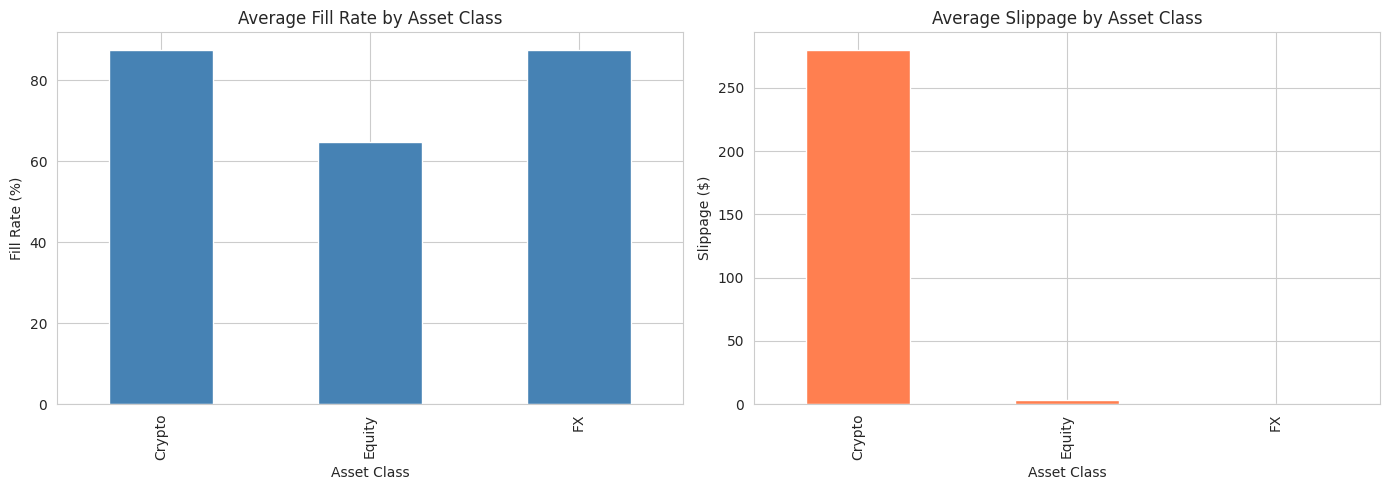

In [6]:
efficiency_query = """
SELECT 
    fi.ticker_symbol,
    fi.asset_class,
    COUNT(o.order_id) as total_orders,
    COUNT(f.fill_id) as filled_orders,
    ROUND(100.0 * COUNT(f.fill_id) / NULLIF(COUNT(o.order_id), 0), 2) as fill_rate_pct,
    ROUND(AVG(o.requested_quantity), 2) as avg_order_size,
    ROUND(AVG(f.executed_quantity), 2) as avg_execution_size,
    ROUND(100.0 * AVG(f.executed_quantity) / NULLIF(AVG(o.requested_quantity), 0), 2) as avg_execution_pct,
    ROUND(AVG(ABS(f.executed_price - COALESCE((SELECT ask_price FROM market_quotes mq2 WHERE mq2.instrument_id = fi.instrument_id ORDER BY mq2.quote_timestamp DESC LIMIT 1), f.executed_price))), 4) as avg_slippage,
    COUNT(CASE WHEN o.order_status = 'REJECTED' THEN 1 END) as rejections
FROM financial_instruments fi
LEFT JOIN orders o ON fi.instrument_id = o.instrument_id
LEFT JOIN fills f ON o.order_id = f.order_id
GROUP BY fi.instrument_id, fi.ticker_symbol, fi.asset_class
HAVING COUNT(o.order_id) > 0
ORDER BY total_orders DESC;
"""

efficiency_df = query_to_df(efficiency_query)
print(f"\n⚡ ORDER EXECUTION EFFICIENCY ({len(efficiency_df)} instruments)")
print("="*150)
display(efficiency_df)

# Visualization: Fill rates by asset class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
efficiency_by_class = efficiency_df.groupby('asset_class')[['fill_rate_pct', 'avg_slippage']].mean()
efficiency_by_class['fill_rate_pct'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Fill Rate by Asset Class')
axes[0].set_ylabel('Fill Rate (%)')
axes[0].set_xlabel('Asset Class')

efficiency_by_class['avg_slippage'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Slippage by Asset Class')
axes[1].set_ylabel('Slippage ($)')
axes[1].set_xlabel('Asset Class')
plt.tight_layout()
plt.show()

---

# 📊 PRIYA'S COMMERCIAL ANALYTICS DASHBOARD
## Commercial Analyst - Executive Reporting & Trends

**Purpose**: Monthly reporting on trading volumes, client activity, and risk metrics for the executive committee. Optimized for historical analysis without impacting live trading.

**Key Responsibilities**:
- Monthly trading volume reports
- Client activity trends
- Risk metrics & risk-adjusted returns
- Executive committee presentations

## 1. Monthly Trading Volume Trends

Executive summary of trading activity by month, comparing volumes and participation.


📈 MONTHLY TRADING VOLUME SUMMARY


,month,active_clients,total_orders,total_shares_executed,total_gmv,avg_order_size,fill_rate_pct,instruments_traded
0,2026-09-01,10,57,120.0,452416.4547,2.11,70.18,12


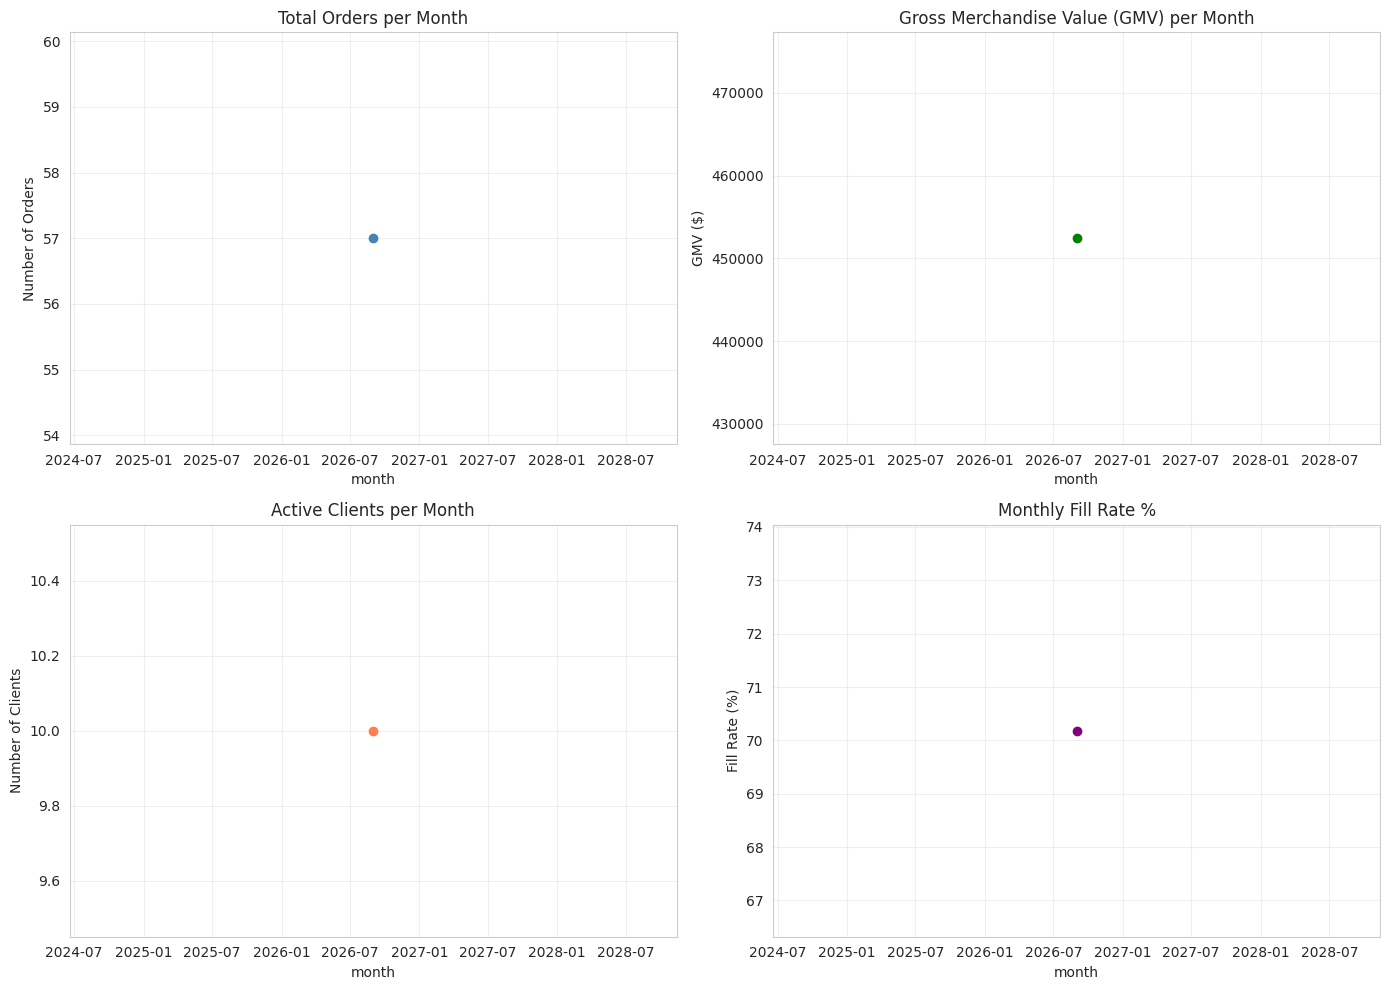

In [7]:
volume_query = """
SELECT 
    DATE_TRUNC('month', o.submitted_at)::DATE as month,
    COUNT(DISTINCT o.client_id) as active_clients,
    COUNT(o.order_id) as total_orders,
    SUM(COALESCE(f.executed_quantity, 0)) as total_shares_executed,
    SUM(COALESCE(f.executed_quantity * f.executed_price, 0)) as total_gmv,
    ROUND(AVG(COALESCE(f.executed_quantity, 0)), 2) as avg_order_size,
    ROUND(100.0 * COUNT(f.fill_id) / NULLIF(COUNT(o.order_id), 0), 2) as fill_rate_pct,
    COUNT(DISTINCT o.instrument_id) as instruments_traded
FROM orders o
LEFT JOIN fills f ON o.order_id = f.order_id
GROUP BY DATE_TRUNC('month', o.submitted_at)
ORDER BY month DESC;
"""

volume_df = query_to_df(volume_query)
print(f"\n📈 MONTHLY TRADING VOLUME SUMMARY")
print("="*150)
display(volume_df)

# Monthly GMV trend visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Orders
volume_df.set_index('month')['total_orders'].plot(ax=axes[0, 0], marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('Total Orders per Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].grid(True, alpha=0.3)

# GMV
volume_df.set_index('month')['total_gmv'].plot(ax=axes[0, 1], marker='o', color='green', linewidth=2)
axes[0, 1].set_title('Gross Merchandise Value (GMV) per Month')
axes[0, 1].set_ylabel('GMV ($)')
axes[0, 1].grid(True, alpha=0.3)

# Active Clients
volume_df.set_index('month')['active_clients'].plot(ax=axes[1, 0], marker='o', color='coral', linewidth=2)
axes[1, 0].set_title('Active Clients per Month')
axes[1, 0].set_ylabel('Number of Clients')
axes[1, 0].grid(True, alpha=0.3)

# Fill Rate
volume_df.set_index('month')['fill_rate_pct'].plot(ax=axes[1, 1], marker='o', color='purple', linewidth=2)
axes[1, 1].set_title('Monthly Fill Rate %')
axes[1, 1].set_ylabel('Fill Rate (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Client Activity Segmentation

Understand client behavior by segment: active traders, growth potential, at-risk clients.


👥 CLIENT ACTIVITY SEGMENTATION (10 clients)


,client_id,client_full_name,risk_profile,trades_lifetime,shares_executed,lifetime_gmv,current_cash,num_holdings,days_since_last_trade,activity_segment
0,45,David Wilson,Adventurous,45,135.0,36411.2650,2.249672e+09,5,4.0,High Activity
1,44,Lisa Anderson,Cautious,30,80.0,936778.3225,1.494379e+09,5,4.0,High Activity
2,46,Jessica Lee,Balanced,28,44.0,397375.3588,1.397218e+09,4,4.0,High Activity
3,49,Edward Martin,Balanced,27,36.0,10213.6263,1.349908e+09,3,2.0,High Activity
4,41,James Mitchell,Balanced,24,52.0,196839.4464,1.198819e+09,4,1.0,High Activity
5,42,Sarah Davies,Adventurous,16,44.0,381074.2832,7.984757e+08,4,3.0,Medium Activity
6,47,Robert Taylor,Balanced,12,30.0,7364.0058,5.999705e+08,3,3.0,Medium Activity
7,43,Michael Brown,Balanced,10,4.0,6200.5332,4.999690e+08,2,1.0,Low Activity
8,48,Catherine Hall,Cautious,9,33.0,11520.7017,4.499654e+08,3,5.0,Low Activity
9,40,Emma Thompson,Cautious,8,14.0,2313.1078,3.999907e+08,2,1.0,Low Activity



📊 SEGMENT DISTRIBUTION:
activity_segment
High Activity      5
Low Activity       3
Medium Activity    2
Name: count, dtype: int64


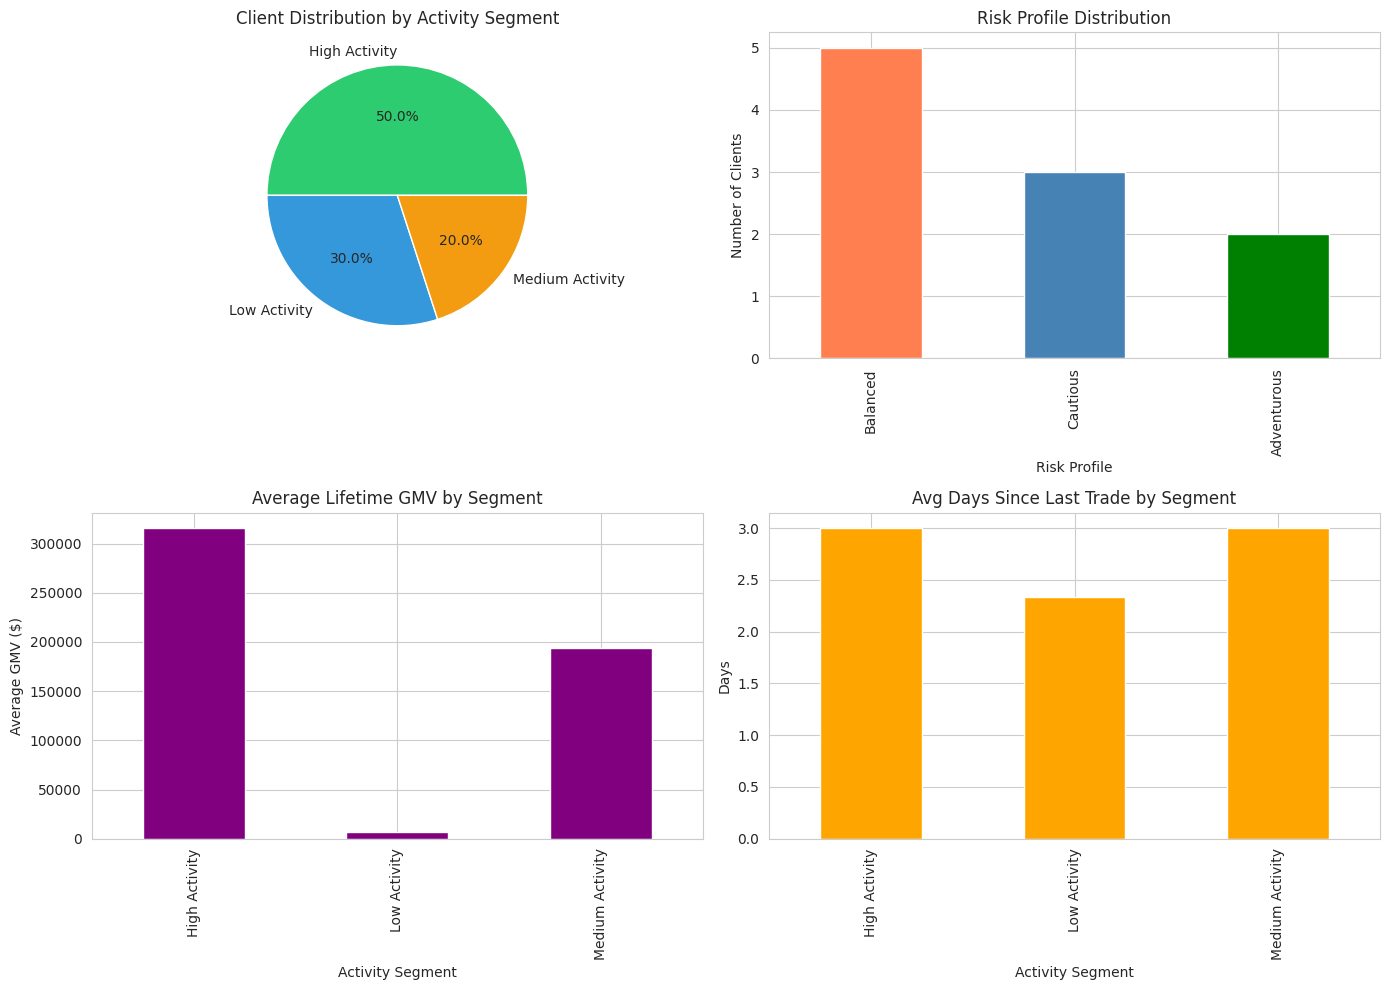

In [8]:
activity_query = """
SELECT 
    cp.client_id,
    cp.client_full_name,
    cp.risk_profile,
    COUNT(o.order_id) as trades_lifetime,
    SUM(COALESCE(f.executed_quantity, 0)) as shares_executed,
    SUM(COALESCE(f.executed_quantity * f.executed_price, 0)) as lifetime_gmv,
    SUM(ca.cash_balance) as current_cash,
    COUNT(DISTINCT ah.instrument_id) as num_holdings,
    EXTRACT(DAY FROM (NOW() - MAX(o.submitted_at))) as days_since_last_trade,
    CASE 
        WHEN COUNT(o.order_id) > 20 THEN 'High Activity'
        WHEN COUNT(o.order_id) > 10 THEN 'Medium Activity'
        WHEN COUNT(o.order_id) > 0 THEN 'Low Activity'
        ELSE 'Dormant'
    END as activity_segment
FROM client_profiles cp
LEFT JOIN orders o ON cp.client_id = o.client_id
LEFT JOIN fills f ON o.order_id = f.order_id
LEFT JOIN client_accounts ca ON cp.client_id = ca.client_id
LEFT JOIN account_holdings ah ON ca.account_id = ah.account_id
GROUP BY cp.client_id, cp.client_full_name, cp.risk_profile
ORDER BY trades_lifetime DESC;
"""

activity_df = query_to_df(activity_query)
print(f"\n👥 CLIENT ACTIVITY SEGMENTATION ({len(activity_df)} clients)")
print("="*150)
display(activity_df)

# Segment distribution
segment_summary = activity_df['activity_segment'].value_counts()
print(f"\n📊 SEGMENT DISTRIBUTION:")
print(segment_summary)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Activity segment pie chart
segment_summary.plot(kind='pie', ax=axes[0, 0], autopct='%1.1f%%', colors=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])
axes[0, 0].set_title('Client Distribution by Activity Segment')
axes[0, 0].set_ylabel('')

# Risk profile distribution
activity_df['risk_profile'].value_counts().plot(kind='bar', ax=axes[0, 1], color=['coral', 'steelblue', 'green'])
axes[0, 1].set_title('Risk Profile Distribution')
axes[0, 1].set_ylabel('Number of Clients')
axes[0, 1].set_xlabel('Risk Profile')

# GMV by segment
activity_df.groupby('activity_segment')['lifetime_gmv'].mean().plot(kind='bar', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Average Lifetime GMV by Segment')
axes[1, 0].set_ylabel('Average GMV ($)')
axes[1, 0].set_xlabel('Activity Segment')

# Days since last trade
activity_df.groupby('activity_segment')['days_since_last_trade'].mean().plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Avg Days Since Last Trade by Segment')
axes[1, 1].set_ylabel('Days')
axes[1, 1].set_xlabel('Activity Segment')

plt.tight_layout()
plt.show()

## 3. Risk Analytics & Portfolio Health

Portfolio concentration, asset allocation alignment, and risk-adjusted metrics.


⚠️ PORTFOLIO RISK ANALYSIS (10 clients)

📊 Risk Metrics Summary:



,Client ID,Client Name,Risk Profile,Cash Position,# Securities,Equity %,Bonds %,Alternatives %,Concentration Risk,Oversized Pos,Largest Pos %
0,45,David Wilson,Adventurous,$250.0M,5,60.0%,0.0%,40.0%,3.36,4,37.0%
1,49,Edward Martin,Balanced,$150.0M,3,100.0%,0.0%,0.0%,2.65,2,50.0%
2,41,James Mitchell,Balanced,$199.8M,4,75.0%,0.0%,25.0%,2.06,2,38.5%
3,42,Sarah Davies,Adventurous,$199.6M,4,50.0%,0.0%,50.0%,1.50,1,45.5%
4,44,Lisa Anderson,Cautious,$249.1M,5,60.0%,0.0%,40.0%,1.48,2,31.2%
5,47,Robert Taylor,Balanced,$150.0M,3,100.0%,0.0%,0.0%,1.15,2,40.0%
6,46,Jessica Lee,Balanced,$199.6M,4,50.0%,0.0%,50.0%,0.96,1,36.4%
7,40,Emma Thompson,Cautious,$100.0M,2,50.0%,0.0%,50.0%,0.71,1,57.1%
8,48,Catherine Hall,Cautious,$150.0M,3,100.0%,0.0%,0.0%,0.58,2,36.4%
9,43,Michael Brown,Balanced,$100.0M,2,50.0%,0.0%,50.0%,0.00,0,50.0%


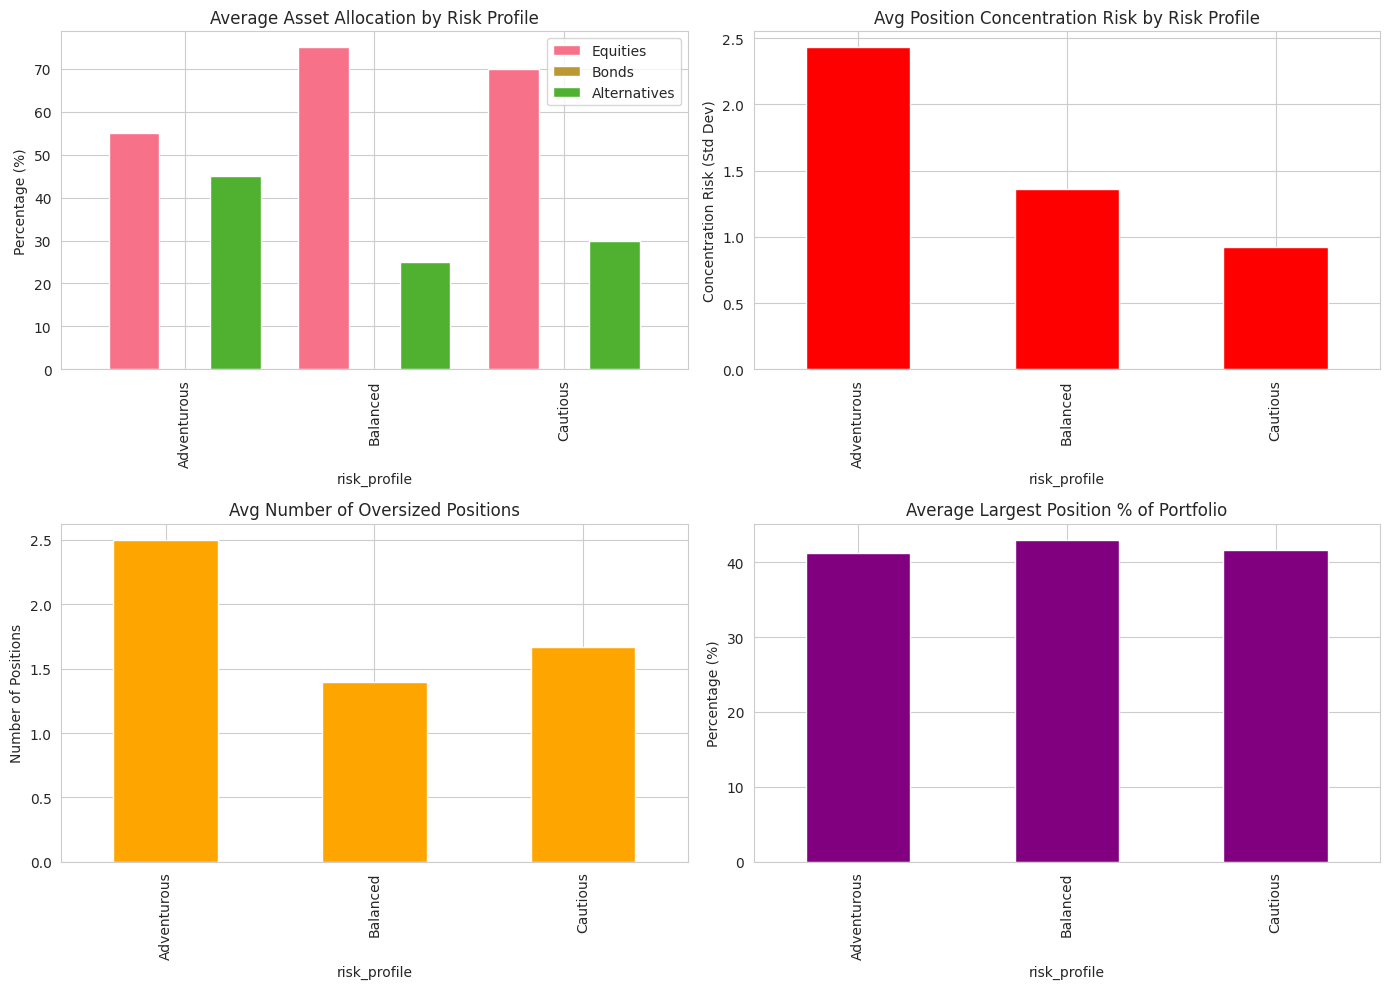

In [9]:
risk_query = """
SELECT 
    cp.client_id,
    cp.client_full_name,
    cp.risk_profile,
    SUM(ca.cash_balance) as cash_position,
    COUNT(DISTINCT ah.instrument_id) as num_securities,
    ROUND(100.0 * COUNT(CASE WHEN fi.asset_class = 'Equity' THEN 1 END) / NULLIF(COUNT(DISTINCT ah.instrument_id), 0), 2) as equity_pct,
    ROUND(100.0 * COUNT(CASE WHEN fi.asset_class = 'Bond' THEN 1 END) / NULLIF(COUNT(DISTINCT ah.instrument_id), 0), 2) as bond_pct,
    ROUND(100.0 * COUNT(CASE WHEN fi.asset_class IN ('Crypto', 'FX') THEN 1 END) / NULLIF(COUNT(DISTINCT ah.instrument_id), 0), 2) as alternative_pct,
    ROUND(STDDEV(COALESCE(ah.quantity, 0)), 2) as position_concentration_risk,
    COUNT(CASE WHEN ah.quantity > (SELECT AVG(quantity) FROM account_holdings) THEN 1 END) as oversized_positions,
    ROUND(100.0 * MAX(ah.quantity) / NULLIF(SUM(ah.quantity), 0), 2) as largest_position_pct
FROM client_profiles cp
LEFT JOIN client_accounts ca ON cp.client_id = ca.client_id
LEFT JOIN account_holdings ah ON ca.account_id = ah.account_id
LEFT JOIN financial_instruments fi ON ah.instrument_id = fi.instrument_id
GROUP BY cp.client_id, cp.client_full_name, cp.risk_profile
ORDER BY position_concentration_risk DESC;
"""

risk_df = query_to_df(risk_query)

# Format the dataframe for display
risk_display = risk_df.copy()
risk_display['cash_position'] = risk_display['cash_position'].apply(lambda x: f"${x/1e6:.1f}M")
risk_display['equity_pct'] = risk_display['equity_pct'].apply(lambda x: f"{x:.1f}%")
risk_display['bond_pct'] = risk_display['bond_pct'].apply(lambda x: f"{x:.1f}%")
risk_display['alternative_pct'] = risk_display['alternative_pct'].apply(lambda x: f"{x:.1f}%")
risk_display['position_concentration_risk'] = risk_display['position_concentration_risk'].apply(lambda x: f"{x:.2f}")
risk_display['largest_position_pct'] = risk_display['largest_position_pct'].apply(lambda x: f"{x:.1f}%")
risk_display = risk_display.rename(columns={
    'client_id': 'Client ID',
    'client_full_name': 'Client Name',
    'risk_profile': 'Risk Profile',
    'cash_position': 'Cash Position',
    'num_securities': '# Securities',
    'equity_pct': 'Equity %',
    'bond_pct': 'Bonds %',
    'alternative_pct': 'Alternatives %',
    'position_concentration_risk': 'Concentration Risk',
    'oversized_positions': 'Oversized Pos',
    'largest_position_pct': 'Largest Pos %'
})

print(f"\n⚠️ PORTFOLIO RISK ANALYSIS ({len(risk_df)} clients)")
print("="*200)
print("\n📊 Risk Metrics Summary:\n")

# Apply color formatting to the numeric risk columns in original df for styling
def highlight_high_risk(val):
    if isinstance(val, (int, float)):
        if val > 3.0:  # High concentration risk
            return 'background-color: #ffcccc; font-weight: bold;'
        elif val > 1.5:
            return 'background-color: #ffe6e6;'
    return ''

def highlight_percentage(val):
    if isinstance(val, str) and '%' in val:
        num = float(val.replace('%', ''))
        if num > 50:
            return 'background-color: #fff3cd;'  # Warning color for high alternatives
    return ''

# Display styled table
styled_risk = risk_df.copy()
styled_risk['cash_position'] = styled_risk['cash_position'].apply(lambda x: f"${x/1e6:.1f}M")
styled_risk['equity_pct'] = styled_risk['equity_pct'].apply(lambda x: f"{x:.1f}%")
styled_risk['bond_pct'] = styled_risk['bond_pct'].apply(lambda x: f"{x:.1f}%")
styled_risk['alternative_pct'] = styled_risk['alternative_pct'].apply(lambda x: f"{x:.1f}%")
styled_risk['position_concentration_risk'] = styled_risk['position_concentration_risk'].apply(lambda x: f"{x:.2f}")
styled_risk['largest_position_pct'] = styled_risk['largest_position_pct'].apply(lambda x: f"{x:.1f}%")

display(risk_display)

# Risk metrics by risk profile
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Asset allocation by risk profile
asset_alloc = risk_df.groupby('risk_profile')[['equity_pct', 'bond_pct', 'alternative_pct']].mean()
asset_alloc.plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Average Asset Allocation by Risk Profile')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['Equities', 'Bonds', 'Alternatives'])

# Concentration risk
risk_df.groupby('risk_profile')['position_concentration_risk'].mean().plot(kind='bar', ax=axes[0, 1], color='red')
axes[0, 1].set_title('Avg Position Concentration Risk by Risk Profile')
axes[0, 1].set_ylabel('Concentration Risk (Std Dev)')

# Oversized positions
risk_df.groupby('risk_profile')['oversized_positions'].mean().plot(kind='bar', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Avg Number of Oversized Positions')
axes[1, 0].set_ylabel('Number of Positions')

# Largest position percentage
risk_df.groupby('risk_profile')['largest_position_pct'].mean().plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Average Largest Position % of Portfolio')
axes[1, 1].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

## 4. Executive Summary: Key Performance Indicators

High-level platform metrics for executive committee reporting.


🎯 EXECUTIVE KPI SUMMARY
  Total Clients........................... 10
  Active Traders.......................... 10
  Lifetime Orders......................... 57
  Filled Orders........................... 40
  Fill Rate (%)........................... 70.18
  Total AUM ($)........................... $499,547,584
  Tradable Instruments.................... 12
  Compliance Records...................... 257


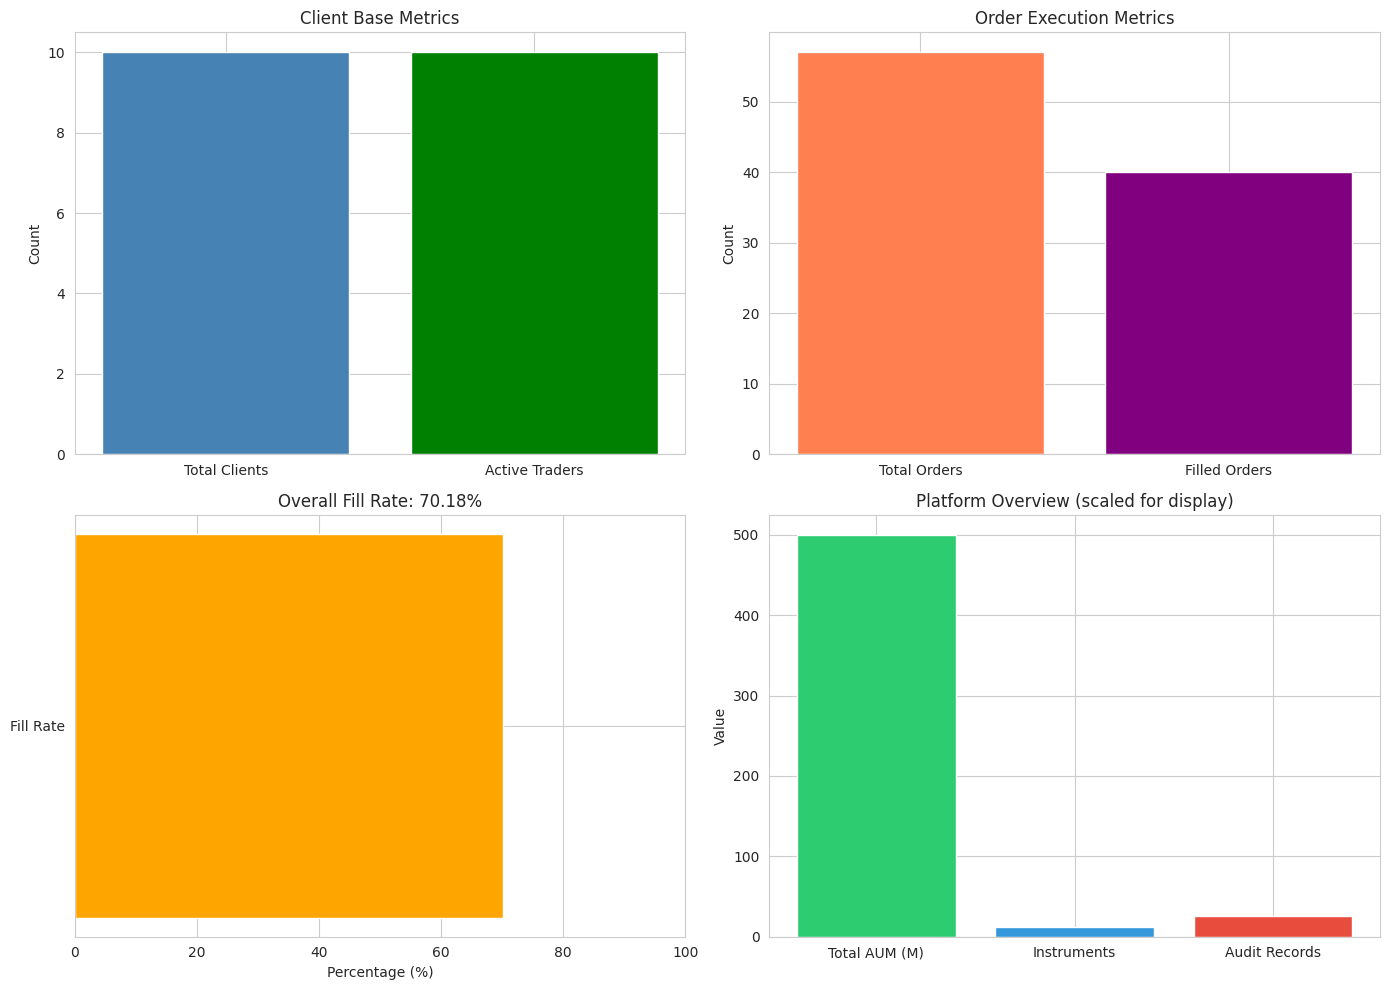

In [10]:
exec_query = """
SELECT 
    (SELECT COUNT(DISTINCT client_id) FROM client_profiles) as total_clients,
    (SELECT COUNT(DISTINCT client_id) FROM orders) as active_trading_clients,
    (SELECT COUNT(*) FROM orders) as total_orders_lifetime,
    (SELECT COUNT(*) FROM fills) as total_filled_orders,
    (SELECT ROUND(100.0 * COUNT(DISTINCT CASE WHEN order_status = 'FILLED' THEN order_id END) / NULLIF(COUNT(*), 0), 2) FROM orders) as overall_fill_rate,
    (SELECT SUM(cash_balance) FROM client_accounts) as total_aum,
    (SELECT COUNT(DISTINCT instrument_id) FROM financial_instruments WHERE is_tradable) as instruments_available,
    (SELECT COUNT(*) FROM audit_logs) as compliance_records;
"""

exec_df = query_to_df(exec_query)
print(f"\n🎯 EXECUTIVE KPI SUMMARY")
print("="*150)

kpis = {
    'Total Clients': exec_df['total_clients'].iloc[0],
    'Active Traders': exec_df['active_trading_clients'].iloc[0],
    'Lifetime Orders': exec_df['total_orders_lifetime'].iloc[0],
    'Filled Orders': exec_df['total_filled_orders'].iloc[0],
    'Fill Rate (%)': exec_df['overall_fill_rate'].iloc[0],
    'Total AUM ($)': f"${exec_df['total_aum'].iloc[0]:,.0f}",
    'Tradable Instruments': exec_df['instruments_available'].iloc[0],
    'Compliance Records': exec_df['compliance_records'].iloc[0]
}

for key, value in kpis.items():
    print(f"  {key:.<40} {value}")

# KPI Dashboard visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Client metrics
client_metrics = [exec_df['total_clients'].iloc[0], exec_df['active_trading_clients'].iloc[0]]
axes[0, 0].bar(['Total Clients', 'Active Traders'], client_metrics, color=['steelblue', 'green'])
axes[0, 0].set_title('Client Base Metrics')
axes[0, 0].set_ylabel('Count')

# Order metrics
order_metrics = [exec_df['total_orders_lifetime'].iloc[0], exec_df['total_filled_orders'].iloc[0]]
axes[0, 1].bar(['Total Orders', 'Filled Orders'], order_metrics, color=['coral', 'purple'])
axes[0, 1].set_title('Order Execution Metrics')
axes[0, 1].set_ylabel('Count')

# Fill rate gauge
fill_rate = exec_df['overall_fill_rate'].iloc[0]
axes[1, 0].barh(['Fill Rate'], [fill_rate], color='green' if fill_rate > 80 else 'orange')
axes[1, 0].set_xlim([0, 100])
axes[1, 0].set_title(f'Overall Fill Rate: {fill_rate}%')
axes[1, 0].set_xlabel('Percentage (%)')

# Platform overview
platform_data = [
    exec_df['total_aum'].iloc[0],
    exec_df['instruments_available'].iloc[0],
    exec_df['compliance_records'].iloc[0]
]
axes[1, 1].bar(['Total AUM (M)', 'Instruments', 'Audit Records'], 
               [platform_data[0]/1e6, platform_data[1], platform_data[2]/10],
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1, 1].set_title('Platform Overview (scaled for display)')
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

---

## 🔧 CUSTOM QUERIES & TROUBLESHOOTING

Use this section for ad-hoc analysis and investigation. Template provided for quick queries.

In [11]:
# CUSTOM QUERY TEMPLATE
# For David: Investigate specific trade disputes or patterns
# For Priya: Deep-dive into specific client segments or time periods

custom_query = """
-- Example: Find all trades for a specific client with dispute history
SELECT 
    o.order_id,
    o.client_id,
    cp.client_full_name,
    o.submitted_at,
    o.order_side,
    fi.ticker_symbol,
    o.requested_quantity,
    f.executed_quantity,
    o.order_status,
    o.rejection_reason
FROM orders o
JOIN client_profiles cp ON o.client_id = cp.client_id
JOIN financial_instruments fi ON o.instrument_id = fi.instrument_id
LEFT JOIN fills f ON o.order_id = f.order_id
WHERE o.client_id = 1  -- Change to your client_id
ORDER BY o.submitted_at DESC;
"""

result = query_to_df(custom_query)
print("Custom Query Result:")
display(result)

Custom Query Result:


,order_id,client_id,client_full_name,submitted_at,order_side,ticker_symbol,requested_quantity,executed_quantity,order_status,rejection_reason
